1. imports and setup

In [47]:
import jax
import jax.numpy as jnp
import jax.random as random
from jax import grad, jit, vmap
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, Callable
from functools import partial

# Set random seed for reproducibility
key = random.PRNGKey(42)

2. reward function definition

In [48]:
def reward_function(x: jnp.ndarray) -> jnp.ndarray:
    """
    Reward function r(x) as defined in the paper.
    Creates a multi-modal landscape for exploration.
    """
    # Multi-modal reward landscape
    reward1 = jnp.exp(-0.5 * jnp.sum((x - jnp.array([2.0, 2.0]))**2, axis=-1))
    reward2 = jnp.exp(-0.5 * jnp.sum((x - jnp.array([-2.0, -2.0]))**2, axis=-1))
    reward3 = 0.5 * jnp.exp(-0.5 * jnp.sum((x - jnp.array([0.0, 3.0]))**2, axis=-1))
    return reward1 + reward2 + reward3

def log_reward(x: jnp.ndarray, beta: float) -> jnp.ndarray:
    """Log of reward-tilted density: beta * r(x)"""
    return beta * reward_function(x)

def score_function(x: jnp.ndarray, beta: float) -> jnp.ndarray:
    """Score function: gradient of log reward"""
    return grad(lambda x: log_reward(x, beta))(x)

3. feynman-kac process

In [49]:
@jit
def feynman_kac_step(x: jnp.ndarray, w: jnp.ndarray, dt: float, 
                     sigma: float, beta: float, key: jnp.ndarray) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Implements Feynman-Kac weighted SDE from equations (29) and (30)
    
    dx_t = sigma^2 * (∇ log q_t(x_t) + β_t/2 * ∇r(x_t)) dt - f_t(x_t) dt + σ_t dW_t
    dw_t = ∂β_t/∂t * r(x_t) dt - ⟨β_t ∇r(x_t), f_t(x_t)⟩ dt + ⟨β_t ∇r(x_t), σ_t^2/2 ∇ log q_t(x_t)⟩ dt
    """
    n_particles = x.shape[0]
    
    # Compute score function (gradient of log density)
    score = vmap(lambda xi: score_function(xi, beta))(x)
    
    # Compute drift term f_t(x_t) - for simplicity, assume zero drift
    f_t = jnp.zeros_like(x)
    
    # Update positions (equation 29)
    drift_x = sigma**2 * (score + beta/2 * vmap(grad(reward_function))(x)) - f_t
    noise_x = sigma * random.normal(key, x.shape)
    x_new = x + drift_x * dt + noise_x * jnp.sqrt(dt)
    
    # Update weights (equation 30) - simplified version
    # Assuming ∂β_t/∂t = 0 for constant beta
    reward_vals = vmap(reward_function)(x)
    drift_w = -beta * jnp.sum(vmap(grad(reward_function))(x) * f_t, axis=1)
    drift_w += beta * sigma**2/2 * jnp.sum(vmap(grad(reward_function))(x) * score, axis=1)
    
    w_new = w + drift_w * dt
    
    return x_new, w_new

4. diffusion process

In [50]:
@jit
def diffusion_step(q: jnp.ndarray, x: jnp.ndarray, dt: float, 
                   sigma: float, f: jnp.ndarray, key: jnp.ndarray) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Implements denoising SDE from equations (14a) and (14b)
    
    ∂q_t^i/∂t = -⟨∇, q_t^i(-f_t + σ_t^2 ∇ log q_t^i)⟩ + σ_t^2/2 Δq_t^i
    dx_t = (-f_t(x_t) + σ_t^2 ∇ log q_t^i(x_t)) dt + σ_t dW_t
    """
    # Compute score (gradient of log density)
    score = vmap(lambda xi: grad(lambda x: jnp.log(jnp.maximum(q[0], 1e-8)))(xi))(x)
    
    # Update density (simplified - in practice would use more sophisticated methods)
    # For particle-based approach, we track particles and their weights
    
    # Update particle positions
    drift = -f + sigma**2 * score
    noise = sigma * random.normal(key, x.shape)
    x_new = x + drift * dt + noise * jnp.sqrt(dt)
    
    return q, x_new

5. budget-constrained resampling

In [51]:
def budget_resampling(particles: jnp.ndarray, weights: jnp.ndarray, 
                     threshold: float, target_low_ratio: float, 
                     budget: int, key: jnp.ndarray) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """
    Budget-constrained resampling with threshold-based particle management
    
    Args:
        particles: Current particle positions
        weights: Current particle weights  
        threshold: Weight threshold for low/high classification
        target_low_ratio: Target proportion of low-weight particles
        budget: Maximum number of reward observations allowed
        
    Returns:
        new_particles, new_weights, observed_indices
    """
    n_particles = len(particles)
    
    # Classify particles by weight
    low_mask = weights < threshold
    high_mask = ~low_mask
    
    n_low_current = jnp.sum(low_mask)
    n_high_current = jnp.sum(high_mask)
    
    # Target numbers
    n_low_target = int(n_particles * target_low_ratio)
    n_high_target = n_particles - n_low_target
    
    # Resample low-weight particles
    if n_low_current < n_low_target:
        # Need more low particles - duplicate existing ones
        if n_low_current > 0:
            low_particles = particles[low_mask]
            low_weights = weights[low_mask]
            # Duplicate randomly to reach target
            dup_indices = random.choice(key, n_low_current, (n_low_target,), replace=True)
            new_low_particles = low_particles[dup_indices]
            new_low_weights = low_weights[dup_indices]
        else:
            # No low particles exist, create from high particles with reduced weight
            high_particles = particles[high_mask]
            sample_indices = random.choice(key, n_high_current, (n_low_target,), replace=True)
            new_low_particles = high_particles[sample_indices]
            new_low_weights = jnp.full(n_low_target, threshold * 0.5)
    else:
        # Too many low particles - subsample proportionally
        low_particles = particles[low_mask]
        low_weights = weights[low_mask]
        keep_indices = random.choice(key, n_low_current, (n_low_target,), replace=False)
        new_low_particles = low_particles[keep_indices]
        new_low_weights = low_weights[keep_indices]
    
    # Resample high-weight particles similarly
    if n_high_current < n_high_target:
        if n_high_current > 0:
            high_particles = particles[high_mask]
            high_weights = weights[high_mask]
            dup_indices = random.choice(key, n_high_current, (n_high_target,), replace=True)
            new_high_particles = high_particles[dup_indices]
            new_high_weights = high_weights[dup_indices]
        else:
            # No high particles - promote from low
            low_particles = particles[low_mask]
            sample_indices = random.choice(key, n_low_current, (n_high_target,), replace=True)
            new_high_particles = low_particles[sample_indices]
            new_high_weights = jnp.full(n_high_target, threshold * 1.5)
    else:
        high_particles = particles[high_mask]
        high_weights = weights[high_mask]
        keep_indices = random.choice(key, n_high_current, (n_high_target,), replace=False)
        new_high_particles = high_particles[keep_indices]
        new_high_weights = high_weights[keep_indices]
    
    # Combine particles
    new_particles = jnp.concatenate([new_low_particles, new_high_particles])
    new_weights = jnp.concatenate([new_low_weights, new_high_weights])
    
    # Determine which particles to observe (budget constraint)
    n_observe = min(budget, n_particles)
    observe_indices = random.choice(key, n_particles, (n_observe,), replace=False)
    
    return new_particles, new_weights, observe_indices

6. weight update and management

In [52]:
@jit
def update_weights_from_rewards(weights: jnp.ndarray, rewards: jnp.ndarray, 
                               observed_indices: jnp.ndarray, beta: float) -> jnp.ndarray:
    """
    Update particle weights based on observed rewards
    """
    new_weights = weights.copy()
    
    # Update weights for observed particles
    observed_rewards = rewards[observed_indices]
    weight_updates = beta * observed_rewards
    new_weights = new_weights.at[observed_indices].add(weight_updates)
    
    # Normalize weights
    new_weights = new_weights - jnp.max(new_weights)  # Numerical stability
    new_weights = jnp.exp(new_weights)
    new_weights = new_weights / jnp.sum(new_weights)
    
    return new_weights

def compute_success_rate(rewards: jnp.ndarray, threshold: float) -> float:
    """Compute proportion of high-reward particles"""
    return jnp.mean(rewards > threshold)

7. visualization functions

In [53]:
def visualize_particles(particles: jnp.ndarray, weights: jnp.ndarray, 
                       rewards: jnp.ndarray, step: int, threshold: float):
    """Visualize particle positions, weights, and reward landscape"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot reward landscape
    x_range = jnp.linspace(-4, 4, 100)
    y_range = jnp.linspace(-4, 4, 100)
    X, Y = jnp.meshgrid(x_range, y_range)
    positions = jnp.stack([X.ravel(), Y.ravel()], axis=1)
    Z = vmap(reward_function)(positions).reshape(100, 100)
    
    ax1.contourf(X, Y, Z, levels=20, alpha=0.7, cmap='viridis')
    ax1.contour(X, Y, Z, levels=10, colors='black', alpha=0.3, linewidths=0.5)
    
    # Plot particles colored by weight
    scatter = ax1.scatter(particles[:, 0], particles[:, 1], 
                         c=weights, s=50, cmap='Reds', alpha=0.8)
    ax1.set_title(f'Particles at Step {step}')
    ax1.set_xlabel('x1')
    ax1.set_ylabel('x2')
    plt.colorbar(scatter, ax=ax1, label='Weight')
    
    # Plot weight distribution
    ax2.hist(weights, bins=20, alpha=0.7, label='Weights')
    ax2.axvline(threshold, color='red', linestyle='--', label=f'Threshold: {threshold}')
    ax2.set_xlabel('Weight')
    ax2.set_ylabel('Count')
    ax2.set_title('Weight Distribution')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    success_rate = compute_success_rate(rewards, threshold)
    print(f"Step {step}: Success rate = {success_rate:.3f}, "
          f"Mean reward = {jnp.mean(rewards):.3f}, "
          f"Mean weight = {jnp.mean(weights):.3f}")

8. main simulation loop

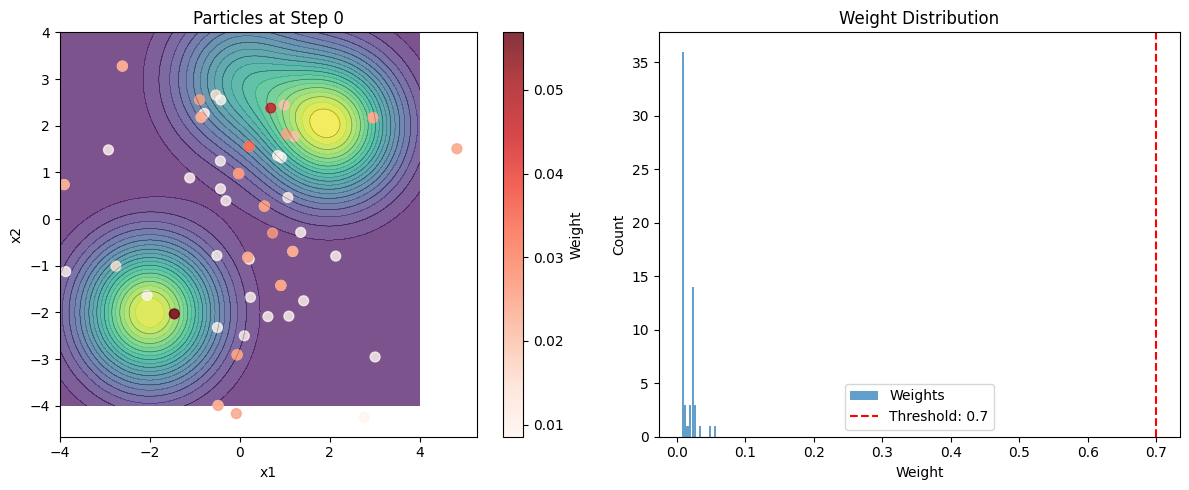

Step 0: Success rate = 0.125, Mean reward = 0.227, Mean weight = 0.016


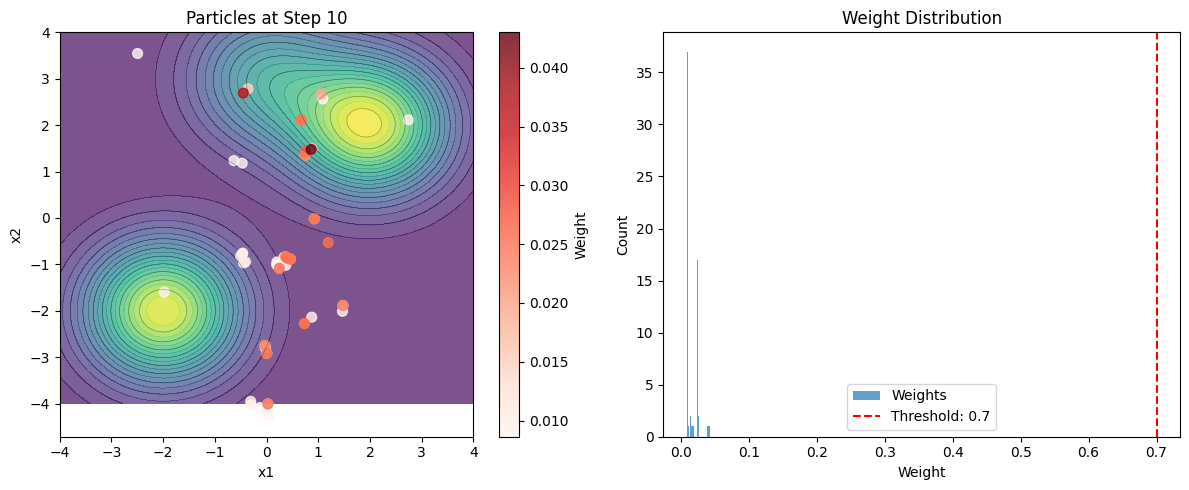

Step 10: Success rate = 0.062, Mean reward = 0.212, Mean weight = 0.016


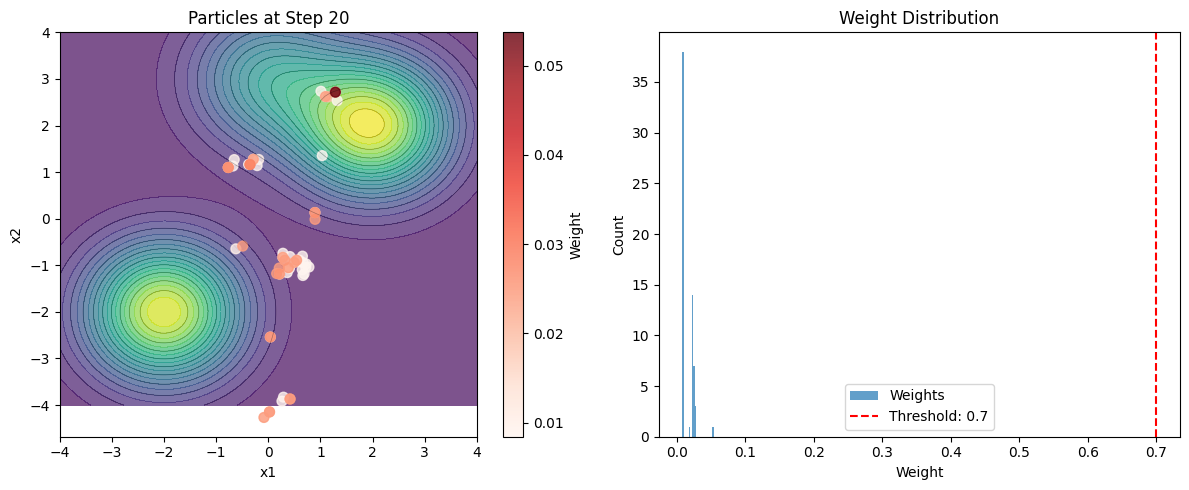

Step 20: Success rate = 0.125, Mean reward = 0.163, Mean weight = 0.016


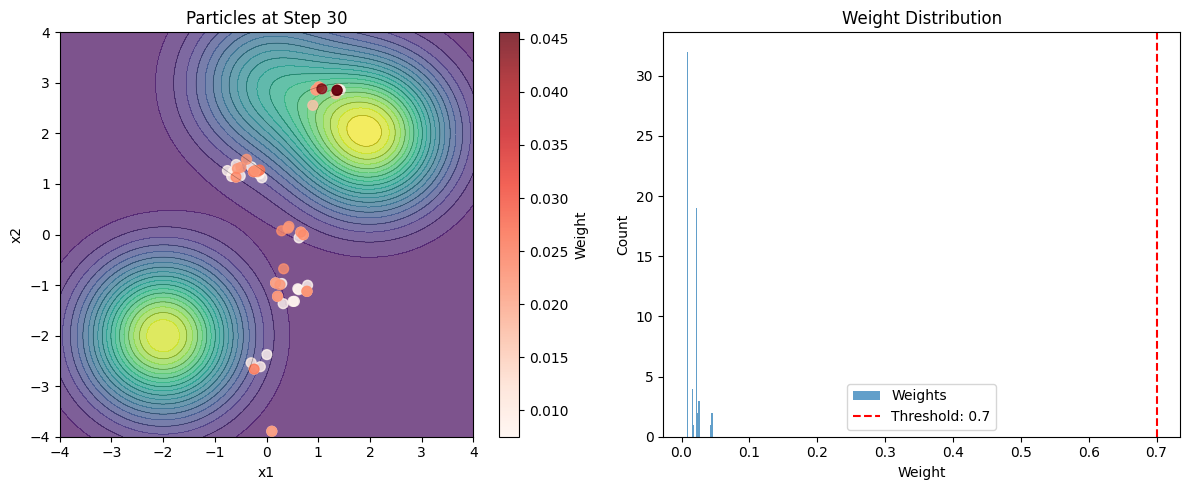

Step 30: Success rate = 0.203, Mean reward = 0.227, Mean weight = 0.016


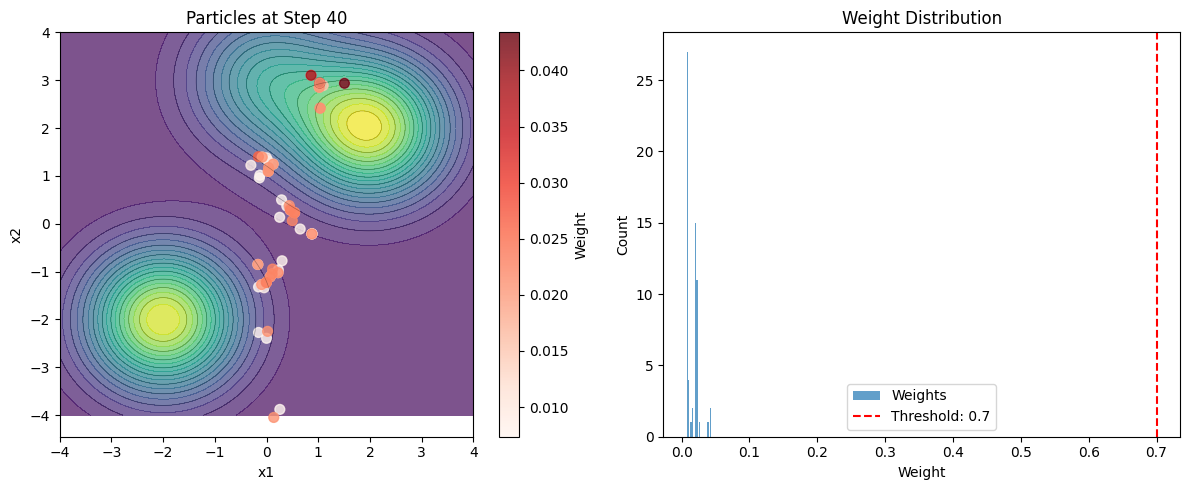

Step 40: Success rate = 0.109, Mean reward = 0.218, Mean weight = 0.016


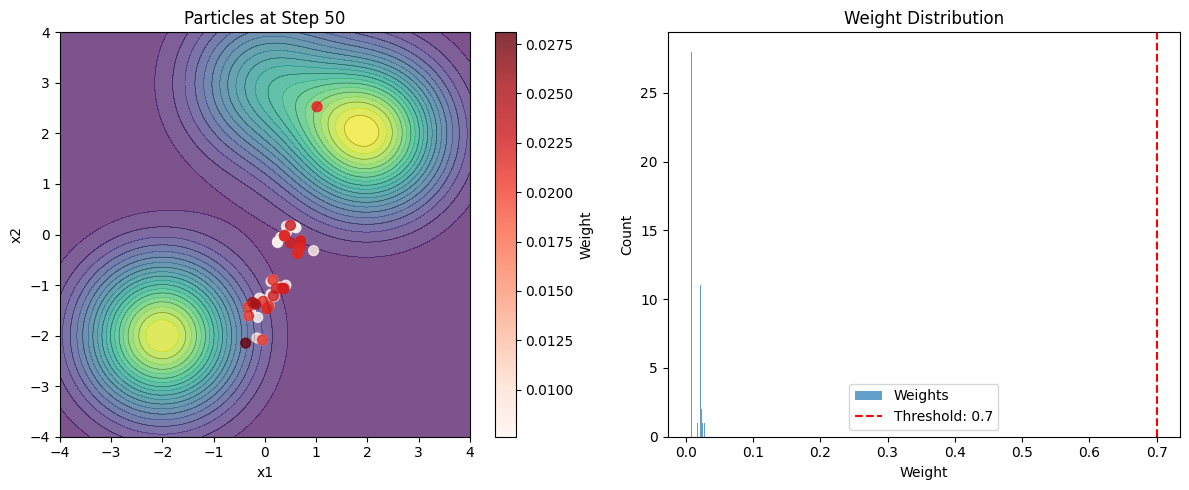

Step 50: Success rate = 0.031, Mean reward = 0.109, Mean weight = 0.016


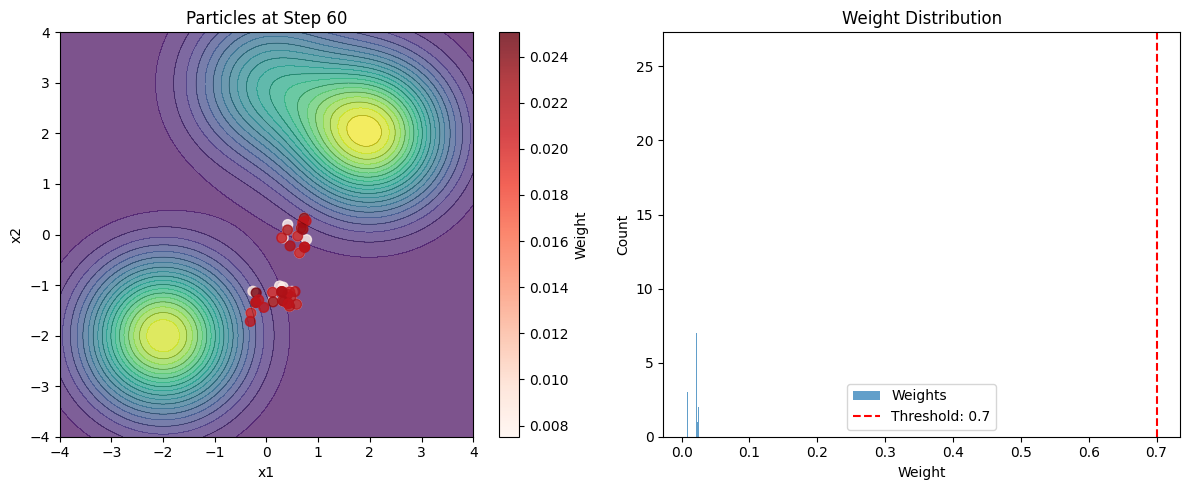

Step 60: Success rate = 0.000, Mean reward = 0.075, Mean weight = 0.016


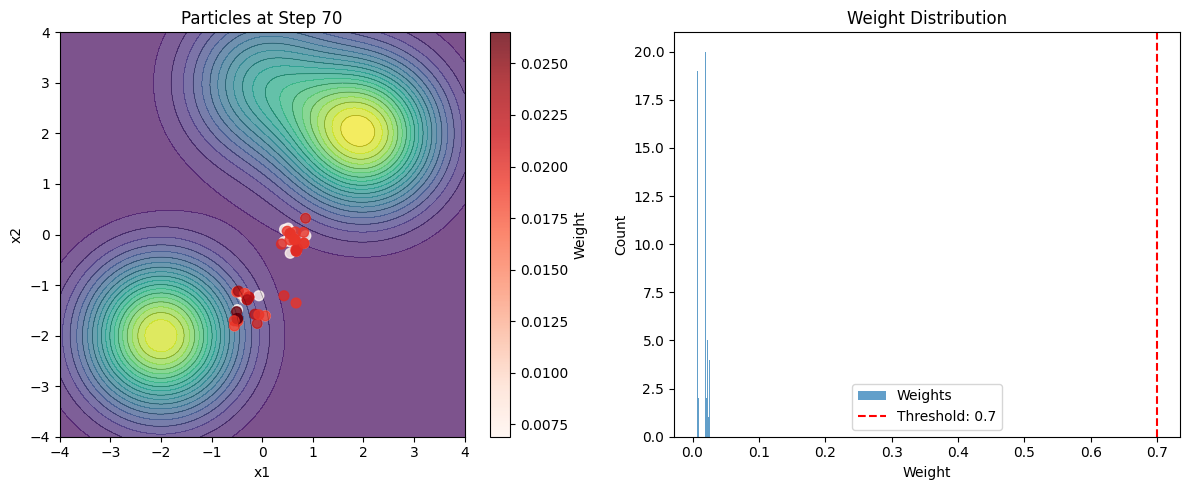

Step 70: Success rate = 0.000, Mean reward = 0.132, Mean weight = 0.016


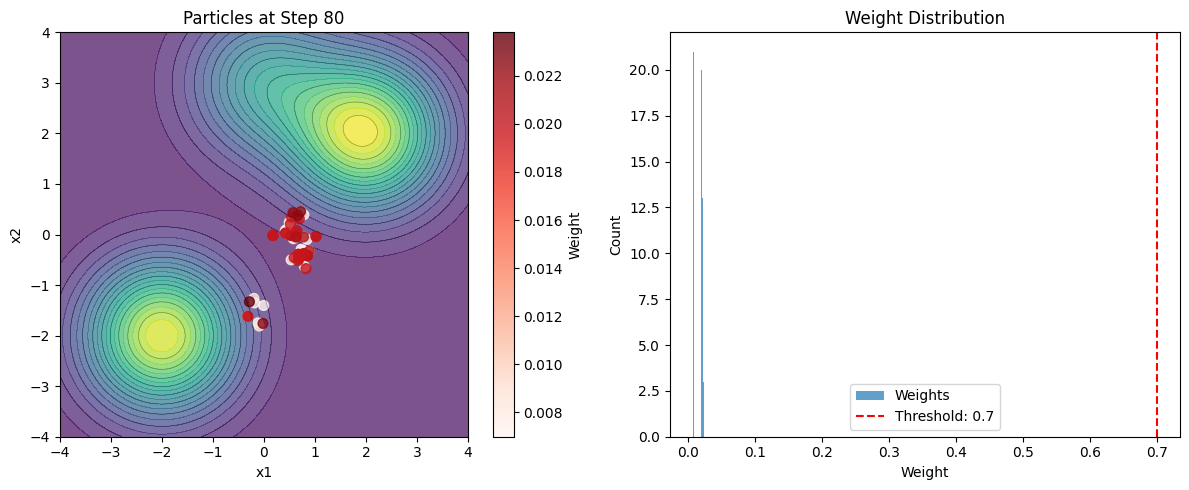

Step 80: Success rate = 0.000, Mean reward = 0.076, Mean weight = 0.016


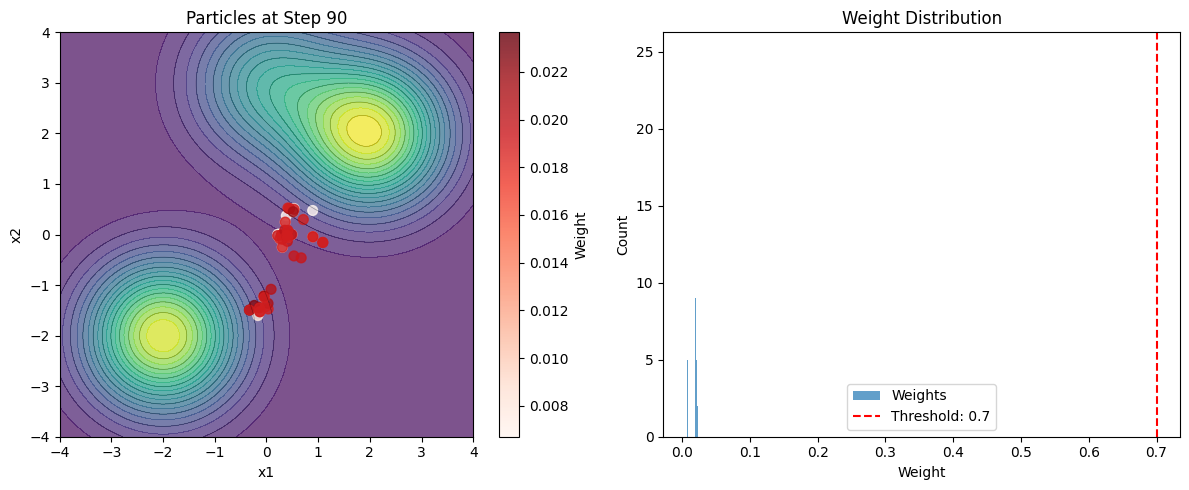

Step 90: Success rate = 0.000, Mean reward = 0.090, Mean weight = 0.016


In [54]:
def run_fkc_diffusion_simulation(n_particles: int = 64, n_steps: int = 100, 
                                budget: int = 32, dt: float = 0.01,
                                sigma: float = 0.5, beta: float = 1.0,
                                threshold: float = 0.7, 
                                target_low_ratio_schedule: Callable = None):
    """
    Main simulation loop for budget-constrained Feynman-Kac diffusion
    """
    if target_low_ratio_schedule is None:
        # Default: start with 70% exploration, end with 30% exploration
        target_low_ratio_schedule = lambda t: 0.7 - 0.4 * t / n_steps
    
    # Initialize particles and weights
    key = random.PRNGKey(42)
    particles = random.normal(key, (n_particles, 2)) * 2.0
    weights = jnp.ones(n_particles) / n_particles
    
    # Storage for metrics
    success_rates = []
    mean_rewards = []
    
    for step in range(n_steps):
        key, subkey = random.split(key)
        
        # Current target ratio for exploration vs exploitation
        target_low_ratio = target_low_ratio_schedule(step)
        
        # Feynman-Kac step
        particles, weights = feynman_kac_step(particles, weights, dt, sigma, beta, subkey)
        
        # Budget-constrained resampling
        key, subkey = random.split(key)
        particles, weights, observed_indices = budget_resampling(
            particles, weights, threshold, target_low_ratio, budget, subkey
        )
        
        # Observe rewards (only for budget-selected particles)
        all_rewards = vmap(reward_function)(particles)
        observed_rewards = all_rewards[observed_indices]
        
        # Update weights based on observed rewards
        weights = update_weights_from_rewards(weights, all_rewards, observed_indices, beta)
        
        # Track metrics
        success_rate = compute_success_rate(all_rewards, threshold)
        success_rates.append(success_rate)
        mean_rewards.append(jnp.mean(all_rewards))
        
        # Visualize every 10 steps
        if step % 10 == 0:
            visualize_particles(particles, weights, all_rewards, step, threshold)
    
    return particles, weights, success_rates, mean_rewards

# Run simulation
final_particles, final_weights, success_rates, mean_rewards = run_fkc_diffusion_simulation()